/var/folders/5j/r_4zgnmx0hjcmtj8nthkgppr0000gn/T/ipykernel_33181/1046091393.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="c", y="rmse", data=rmse_df, palette="pastel", width=0.6, fliersize=0)


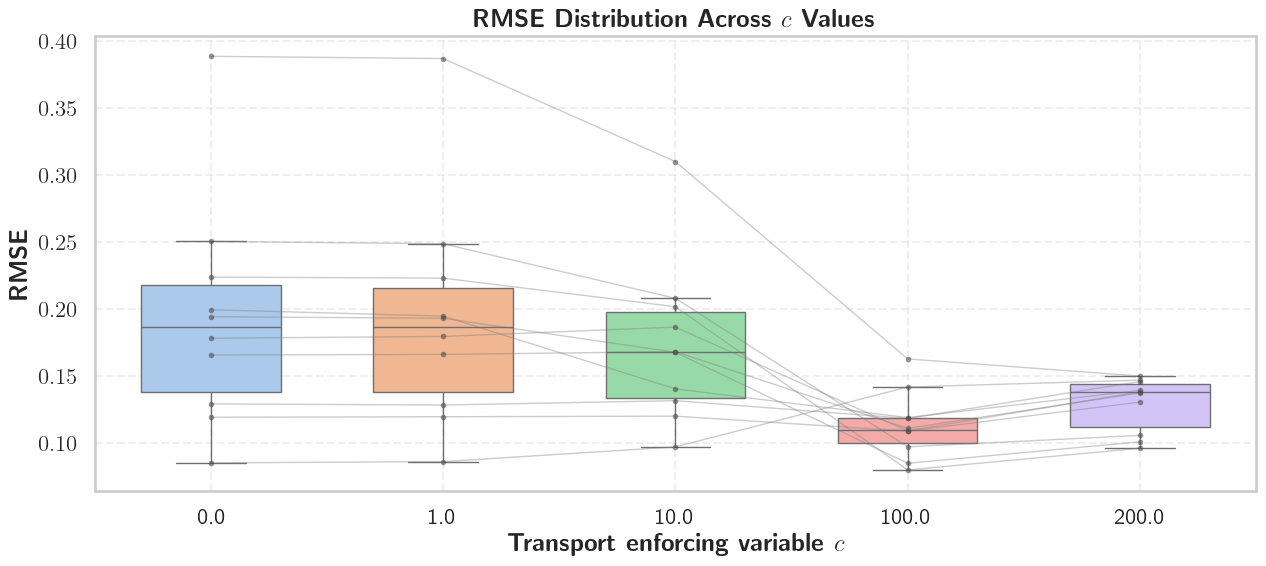

In [3]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = True

# Set seaborn style
sns.set_theme(style="whitegrid", context="talk")

# Folder containing RMSE files
folder_path = "results/"
file_list = glob.glob(os.path.join(folder_path, "RMSE_*.csv"))

# Load and combine all files
all_data = []
for file_path in file_list:
    c_str = os.path.basename(file_path).split("_")[1].replace(".csv", "")
    try:
        c_val = float(c_str)
    except ValueError:
        continue
    df = pd.read_csv(file_path)
    if "seed" not in df.columns:
        raise ValueError(f"'seed' column missing in {file_path}")
    df["c"] = c_val
    all_data.append(df)

rmse_df = pd.concat(all_data, ignore_index=True)
rmse_df["c"] = rmse_df["c"].astype(float)

# Ensure every seed appears for all c values
c_values = sorted(rmse_df["c"].unique())
n_c = len(c_values)
seed_counts = rmse_df.groupby("seed")["c"].nunique()
if not all(seed_counts == n_c):
    raise ValueError("Some seeds are missing for some c values.")

# Map c values to categorical positions used in the boxplot
c_to_x = {c: i for i, c in enumerate(c_values)}
rmse_df["x"] = rmse_df["c"].map(c_to_x)

# 🎨 Start plot
plt.figure(figsize=(13, 6))

# Boxplot using categorical x-axis
sns.boxplot(x="c", y="rmse", data=rmse_df, palette="pastel", width=0.6, fliersize=0)

# ✅ Plot lines with corrected x positions
for seed, group in rmse_df.groupby("seed"):
    group_sorted = group.sort_values("x")
    x_vals = group_sorted["x"]
    y_vals = group_sorted["rmse"]
    plt.plot(x_vals, y_vals, color="gray", alpha=0.4, linewidth=1)

# Stripplot (individual dots) still works
sns.stripplot(x="c", y="rmse", data=rmse_df, color=".3", size=4, jitter=False, alpha=0.6)

# Labels
plt.xlabel(r"\textbf{Transport enforcing variable $c$}")
plt.ylabel(r"\textbf{RMSE}")
plt.title(r"\textbf{RMSE Distribution Across $c$ Values}", fontsize=18)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()

# Save
os.makedirs("plots", exist_ok=True)
plt.savefig("plots/rmse_vs_c_fixed_lines.pdf")
plt.savefig("plots/rmse_vs_c_fixed_lines.svg")
plt.show()

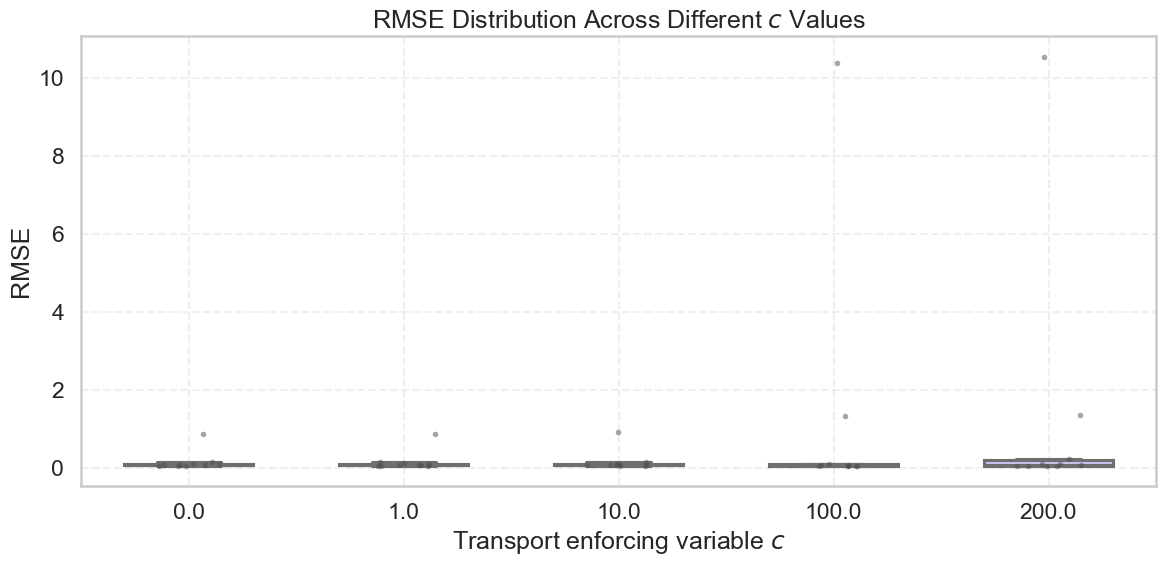

In [1]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Apply a clean Seaborn style
sns.set_theme(style="whitegrid", context="talk")

# Folder containing RMSE_<c>.csv files
folder_path = "results/"
file_list = glob.glob(os.path.join(folder_path, "RMSE_*.csv"))

# Load and combine all RMSE data
all_data = []
for file_path in file_list:
    c_str = os.path.basename(file_path).split("_")[1].replace(".csv", "")
    try:
        c_val = float(c_str)
    except ValueError:
        continue
    df = pd.read_csv(file_path)
    df["c"] = c_val
    all_data.append(df)

rmse_df = pd.concat(all_data, ignore_index=True)
rmse_df["c"] = rmse_df["c"].astype(float)
rmse_df = rmse_df.sort_values("c")

# Create the plot
plt.figure(figsize=(12, 6))
sns.boxplot(x="c", y="rmse", data=rmse_df, palette="pastel", width=0.6, fliersize=0)
sns.stripplot(x="c", y="rmse", data=rmse_df, color=".3", size=4, jitter=0.15, alpha=0.5)

plt.xlabel("Transport enforcing variable $c$")
plt.ylabel("RMSE")
plt.title("RMSE Distribution Across Different $c$ Values", fontsize=18)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()

# Save plot as vector graphics
output_dir = "plots"
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, "rmse_vs_c.pdf"))
plt.savefig(os.path.join(output_dir, "rmse_vs_c.svg"))

plt.show()

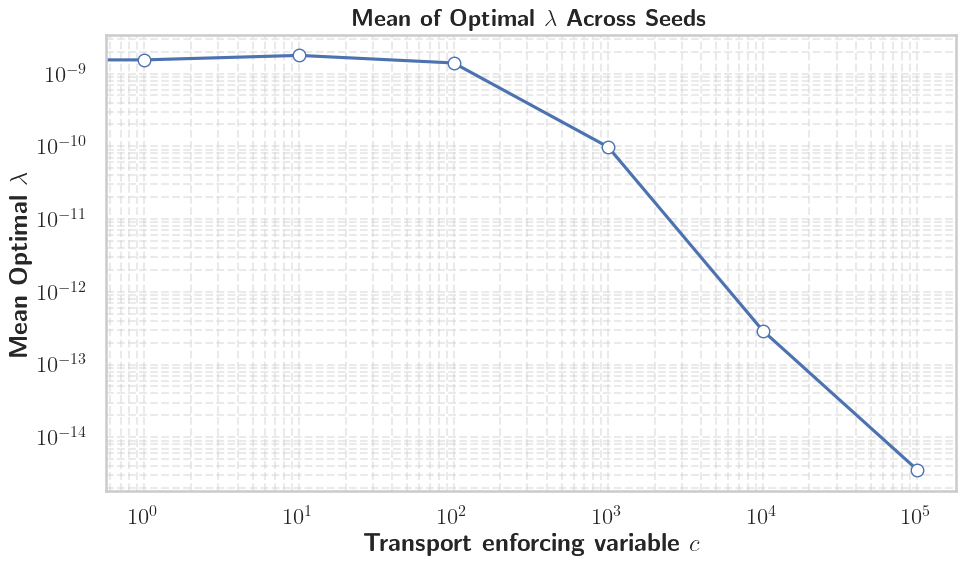

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the CSV
df = pd.read_csv("results/lambdas.csv")
df["c"] = df["c"].astype(float)
df = df.sort_values("c")

# Plot
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid", context="talk")

# Use log-log scale if your lambda and c vary over many orders
plt.errorbar(
    df["c"], df["lambda_mean"],
    fmt='o-', capsize=5, elinewidth=1.5, markerfacecolor='white'
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"\textbf{Transport enforcing variable} $c$")
plt.ylabel(r"\textbf{Mean Optimal $\lambda$ }")
plt.title(r"\textbf{Mean of Optimal $\lambda$ Across Seeds}", fontsize=17)

plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()

# Save
plt.savefig("plots/lambda_vs_c.pdf")
plt.savefig("plots/lambda_vs_c.svg")
plt.show()